In [2]:
import kagglehub

path = kagglehub.dataset_download("nalisha/job-salary-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'job-salary-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/job-salary-prediction-dataset


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Set style for visualizations

sns.set(style="whitegrid")

In [5]:
# Load the dataset
import os
print(os.listdir(path))
df = pd.read_csv(f'{path}/job_salary_prediction_dataset.csv')

['job_salary_prediction_dataset.csv']


In [6]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [7]:
df.isnull().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.info

<bound method DataFrame.info of                  job_title  experience_years education_level  skills_count  \
0              AI Engineer                10        Bachelor             2   
1             Data Analyst                 5        Bachelor            17   
2       Frontend Developer                18             PhD             4   
3         Business Analyst                19             PhD            13   
4          Product Manager                15        Bachelor             7   
...                    ...               ...             ...           ...   
249995   Software Engineer                17             PhD             2   
249996  Frontend Developer                20             PhD             7   
249997    Business Analyst                 1        Bachelor            12   
249998      Data Scientist                 0     High School             2   
249999        Data Analyst                16         Diploma             2   

             industry company_size   location remote_work  certifications  \
0          Healthcare       Medium      India      Hybrid               2   
1             Telecom        Small  Australia          No               0   
2               Media       Medium  Singapore          No               1   
3              Retail       Medium     Canada         Yes               0   
4       Manufacturing        Large     Sweden         Yes               0   
...               ...          ...        ...         ...             ...   
249995        Telecom   Enterprise      India          No               1   
249996        Telecom      Startup     Remote          No               2   
249997         Retail   Enterprise      India         Yes               0   
249998     Consulting        Small     Sweden      Hybrid               5   
249999     Technology       Medium         UK          No               5   

        salary                 Job  \
0       109413         AI Engineer   
1        93764        Data Analyst   
2       148123  Frontend Developer   
3       189123    Business Analyst   
4       165069     Product Manager   
...        ...                 ...   
249995  127791   Software Engineer   
249996  154593  Frontend Developer   
249997   75988    Business Analyst   
249998   90467      Data Scientist   
249999  133084        Data Analyst   

                                            Details  
0              AI Engineer : 10 years of experience  
1              Data Analyst : 5 years of experience  
2       Frontend Developer : 18 years of experience  
3         Business Analyst : 19 years of experience  
4          Product Manager : 15 years of experience  
...                                             ...  
249995   Software Engineer : 17 years of experience  
249996  Frontend Developer : 20 years of experience  
249997     Business Analyst : 1 years of experience  
249998       Data Scientist : 0 years of experience  
249999        Data Analyst : 16 years of experience  

[250000 rows x 12 columns]>

In [16]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


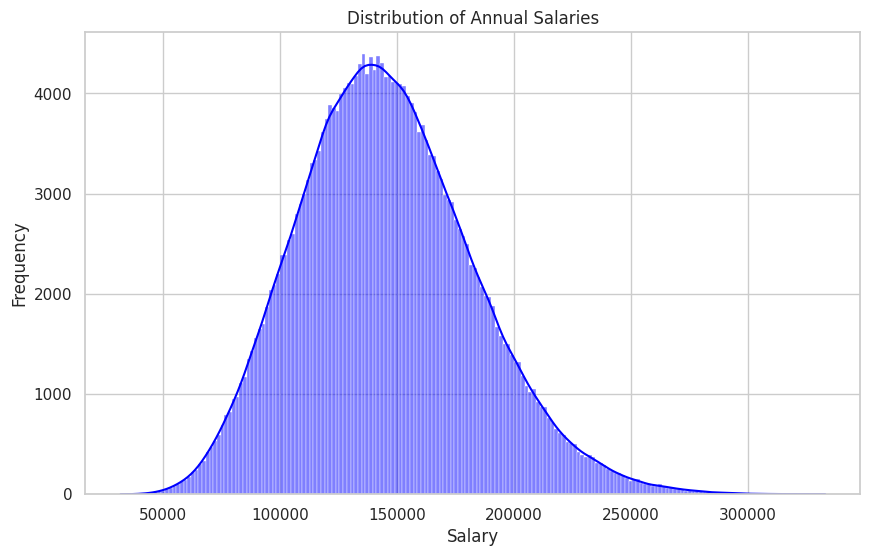

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(df['salary'],
kde=True, color='blue')
plt.title('Distribution of Annual Salaries')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

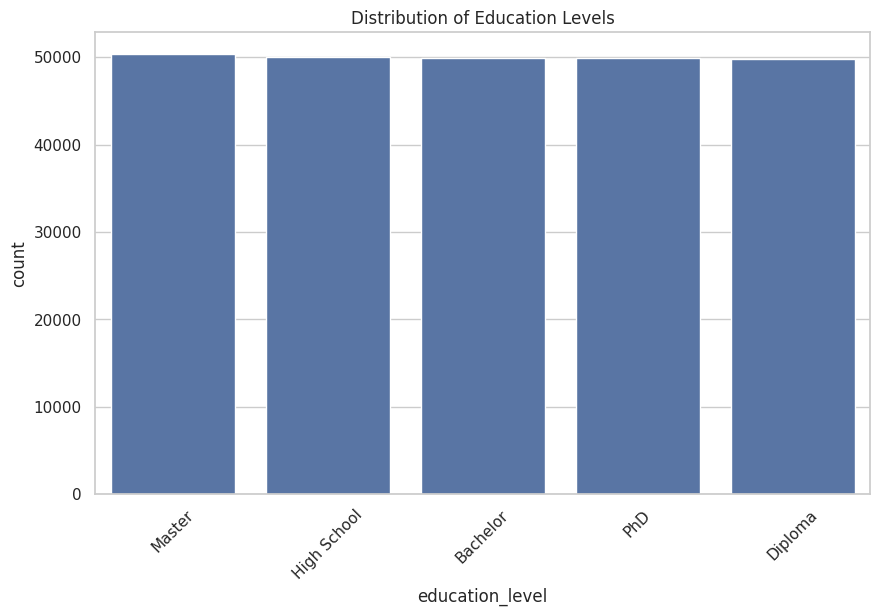

In [18]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='education_level', order=df['education_level'].value_counts().index)
plt.title('Distribution of Education Levels')
plt.xticks(rotation=45)
plt.show()

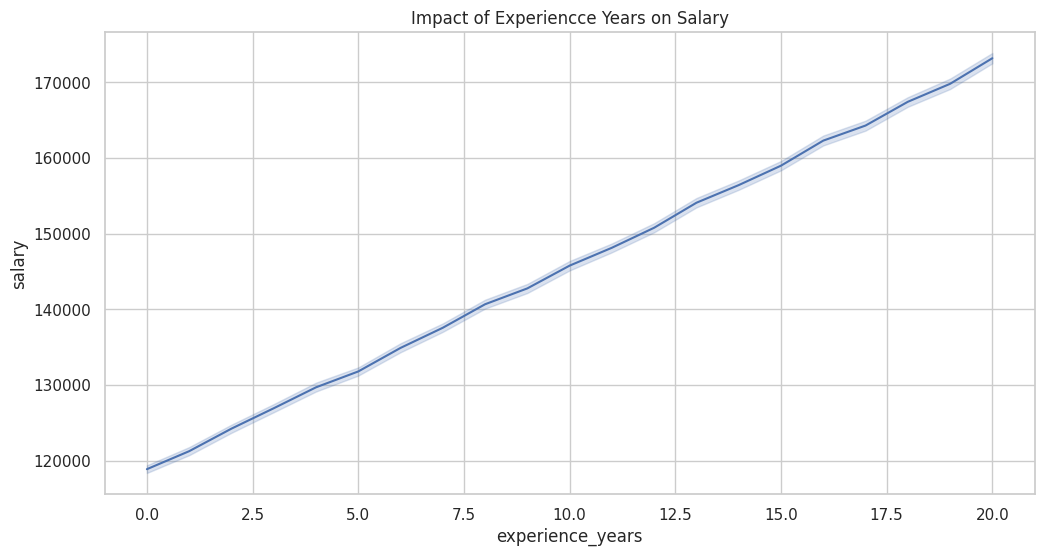

In [19]:

plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='experience_years', y='salary')
plt.title('Impact of Experiencce Years on Salary')
plt.show()

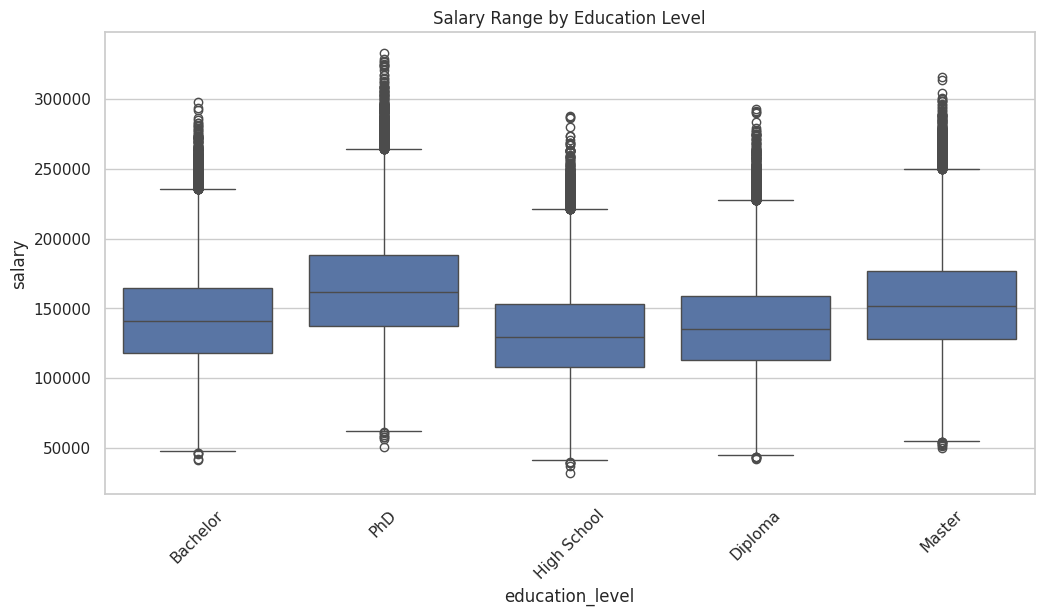

In [20]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='education_level', y='salary')
plt.title('Salary Range by Education Level')
plt.xticks(rotation=45)
plt.show()

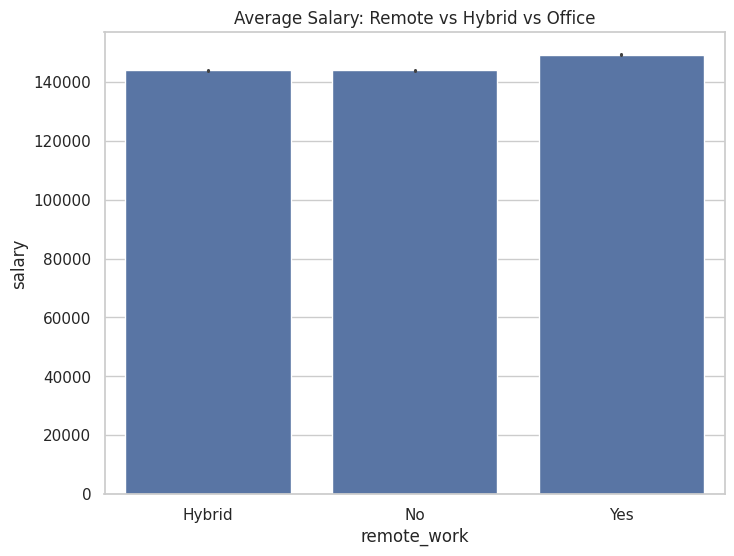

In [21]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='remote_work', y='salary', estimator=np.mean)
plt.title('Average Salary: Remote vs Hybrid vs Office')
plt.show()

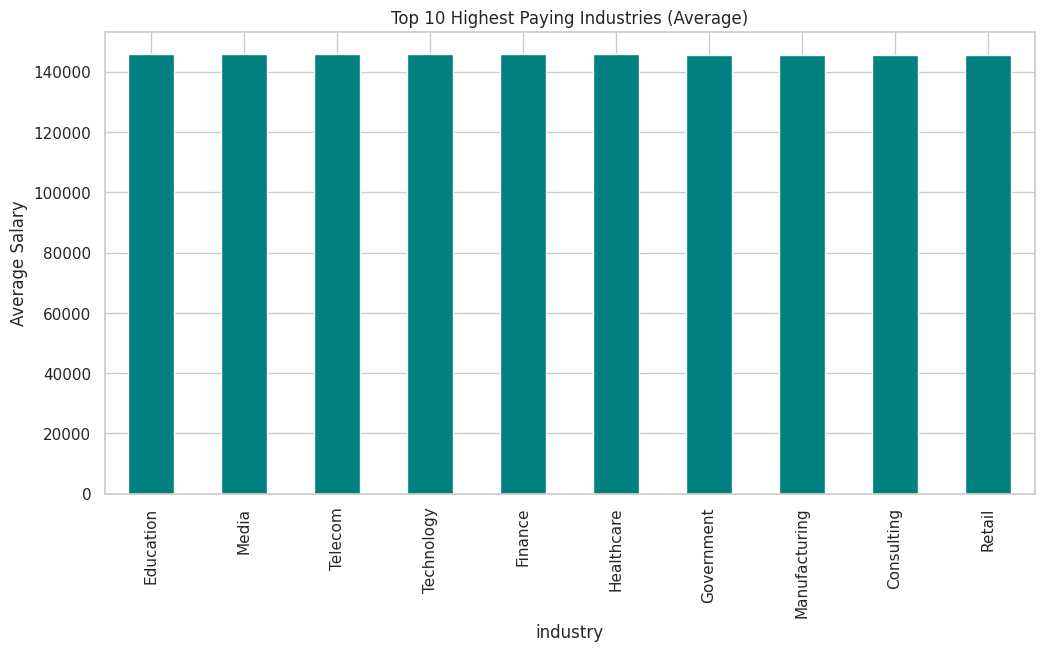

In [22]:
plt.figure(figsize=(12, 6))
top_industries = df.groupby('industry')['salary'].mean().sort_values(ascending=False).head(10)
top_industries.plot(kind='bar', color='teal')
plt.title('Top 10 Highest Paying Industries (Average)')
plt.ylabel('Average Salary')
plt.show()

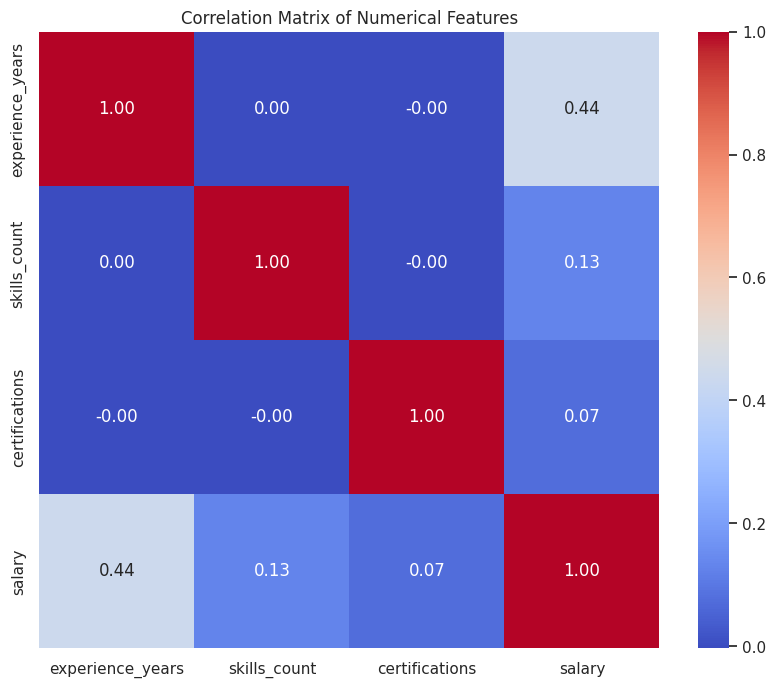

In [23]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt = '.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

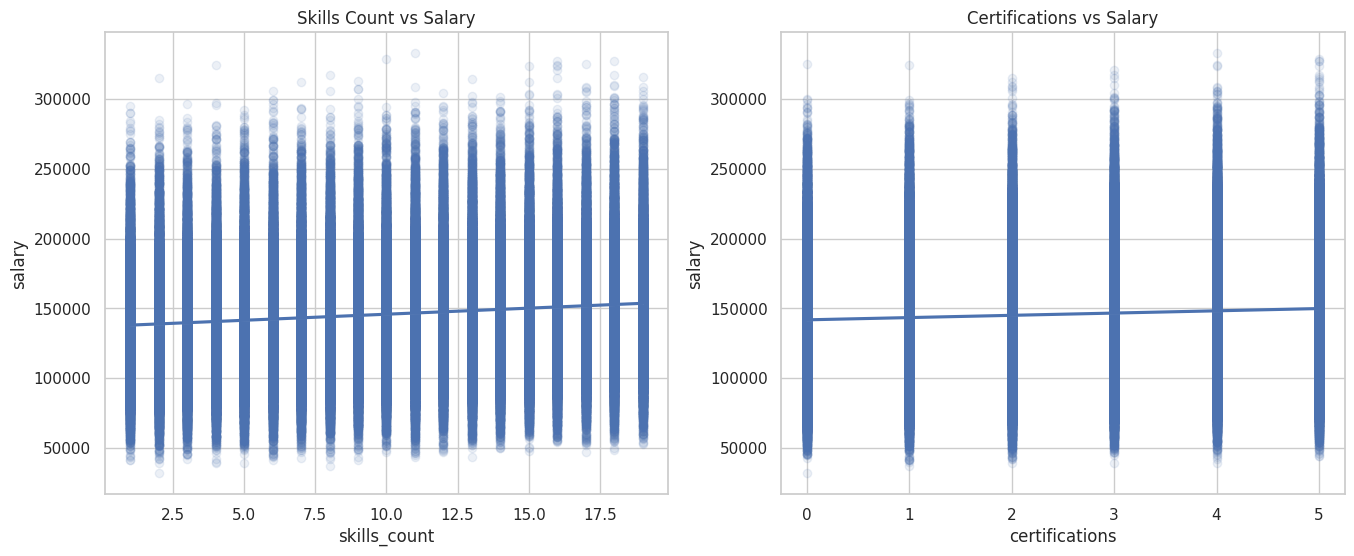

In [24]:
# Checking if more certifications or skills correlate with higher pay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=df,
x='skills_count', y='salary',
ax=ax1, scatter_kws={'alpha':0.1})
ax1.set_title('Skills Count vs Salary')


sns.regplot(data=df,
x='certifications', y='salary',
ax=ax2, scatter_kws={'alpha':0.1})
ax2.set_title('Certifications vs Salary')

plt.show()

In [9]:
df['Job']=df['job_title']
df['Job'].head()

,Job
0,AI Engineer
1,Data Analyst
2,Frontend Developer
3,Business Analyst
4,Product Manager


In [10]:
df['Job'].unique()

array(['AI Engineer', 'Data Analyst', 'Frontend Developer',
       'Business Analyst', 'Product Manager', 'Backend Developer',
       'Machine Learning Engineer', 'DevOps Engineer',
       'Software Engineer', 'Cybersecurity Analyst', 'Data Scientist',
       'Cloud Engineer'], dtype=object)

In [11]:
df['Details']=df['Job']+' : '+df['experience_years'].astype(str)+' years of experience'
df['Details'].head()

,Details
0,AI Engineer : 10 years of experience
1,Data Analyst : 5 years of experience
2,Frontend Developer : 18 years of experience
3,Business Analyst : 19 years of experience
4,Product Manager : 15 years of experience


<Axes: xlabel='Job', ylabel='salary'>

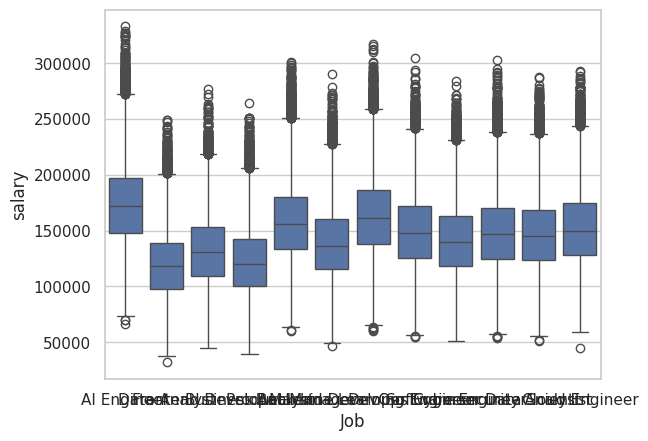

In [12]:
x=df['Job']
y=df['salary']

sns.boxplot(x=x,y=y)


<Axes: xlabel='Job', ylabel='education_level'>

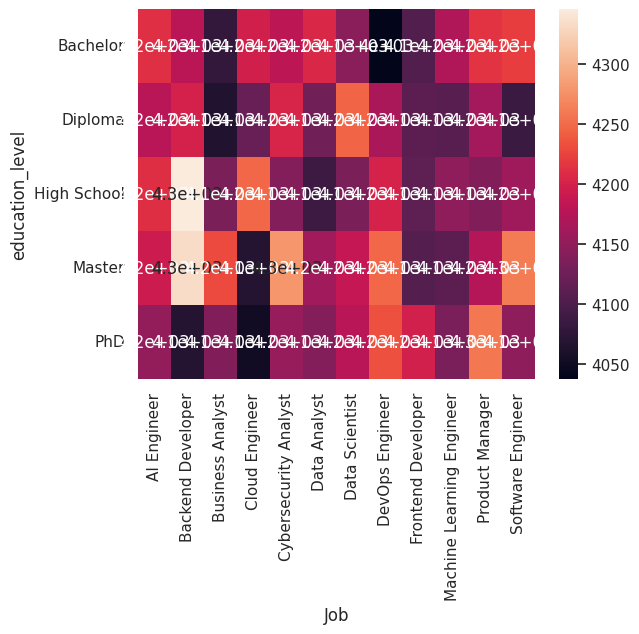

In [13]:
x=df['education_level']

y=df['Job']


sns.heatmap(pd.crosstab(x,y),annot=True)